In [80]:
import numpy as np
import matplotlib.pyplot as plt
import time
from math import pi
from scipy.special import jv, kv, kn
from scipy.optimize import brentq

In [81]:
# Parameters
wavelength = 1.064       
n_core = 1.523
n_clad = 1.520
core_radius = 12.5       
Lz = 1000.0              
bend_radius = 30.0e3     
pe = 0.3                 

k0 = (2 * np.pi) / wavelength 
k = k0 * n_clad

In [82]:
def analytical_mode_numpy(x, y, mode_type='LP21'):
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    V = k0 * core_radius * np.sqrt(n_core**2 - n_clad**2)
    

    l, U = 2, 3.8
        
    W = np.sqrt(V**2 - U**2)
    Jl = jv(l, U * r / core_radius)
    Kl = kn(l, W * r / core_radius)
    Jl_a, Kl_a = jv(l, U), kn(l, W)
    
    angular = np.cos(l * phi)
    field = np.where(r <= core_radius, Jl * angular, (Jl_a / Kl_a) * Kl * angular)
    max_val = np.max(np.abs(field))
    return (field / max_val).astype(np.complex64)



In [83]:
def bent_refractive_index_numpy(x, y, bend_axis='y'):
    r = np.sqrt(x**2 + y**2)
    n_straight = np.where(r <= core_radius, n_core, n_clad)
    coord = x if bend_axis == 'x' else y
    factor1 = 1.0 - (n_straight / 2.0) * pe * (coord / bend_radius)
    factor2 = np.exp(coord / bend_radius)
    return n_straight * factor1 * factor2

In [84]:
window_xy = 200.0
Nx = Ny = 512

Lz = 1000.0
z_points = 500

x0 = np.linspace(-window_xy/2, window_xy/2, Nx)
y0 = np.linspace(-window_xy/2, window_xy/2, Ny)
X, Y = np.meshgrid(x0, y0)

z = np.linspace(0, Lz, z_points + 1)   
dz = z[1] - z[0]    
dx = x0[1] - x0[0] 

target_zs = [0.0, 400.0, 800.0, 1000.0]
bpm_results = {}

Beam = analytical_mode_numpy(X, Y, 'LP21')
bpm_results[0.0] = Beam.copy()

                   
    

# fx = 2 * np.pi * np.fft.fftfreq(Nx, dx)
# fy = 2 * np.pi * np.fft.fftfreq(Nx, dx)
fx = np.fft.fftfreq(Nx, dx)
fy = np.fft.fftfreq(Nx, dx)
FY, FX = np.meshgrid(fx, fy)

B_ref = k0 * n_clad

# H = np.exp(1j * (FX**2 + FY**2) * (dz / 2) / (2 * B_ref))
H = np.exp(1j * np.pi * wavelength * (dz / 2) * (FX**2 + FY**2))

sponge_start = 70.0
mABC = np.ones_like(X)
r = np.sqrt(X**2 + Y**2)
mask_region = r > sponge_start
mABC[mask_region] = np.exp(-0.01 * (r[mask_region] - sponge_start)**2)

mxyn_bent = bent_refractive_index_numpy(X, Y, bend_axis='y')
dn = mxyn_bent - n_clad
Phase_mat = np.exp(-1j * k0 * dz * dn)


In [ ]:
for iz in range(1, z_points + 1):
    Beam = np.fft.ifft2(np.fft.fft2(Beam) * H)
    Beam *= Phase_mat
    Beam = np.fft.ifft2(np.fft.fft2(Beam) * H)
    Beam *= mABC
    
    current_z = iz * dz
    if any(np.isclose(current_z, tz, atol=dz/2) for tz in target_zs):
        tz = min(target_zs, key=lambda x: abs(x - current_z))
        if tz not in bpm_results:
            bpm_results[tz] = Beam.copy()
            print(f"Captured BPM field at z = {tz} μm")

Captured BPM field at z = 400.0 μm
Captured BPM field at z = 800.0 μm
Captured BPM field at z = 1000.0 μm


In [92]:
# for z, field in bpm_results.items():
#     plt.figure()
#     plt.imshow(np.abs(field)**2, extent=[-window_xy/2, window_xy/2, -window_xy/2, window_xy/2], origin='lower', cmap='jet')
#     plt.colorbar()
#     plt.title(f"Intensity at z = {z} µm")
#     plt.xlim([-30, 30])
#     plt.ylim([-30, 30])
#     plt.xlabel("x (µm)")
#     plt.ylabel("y (µm)")
#     plt.show()

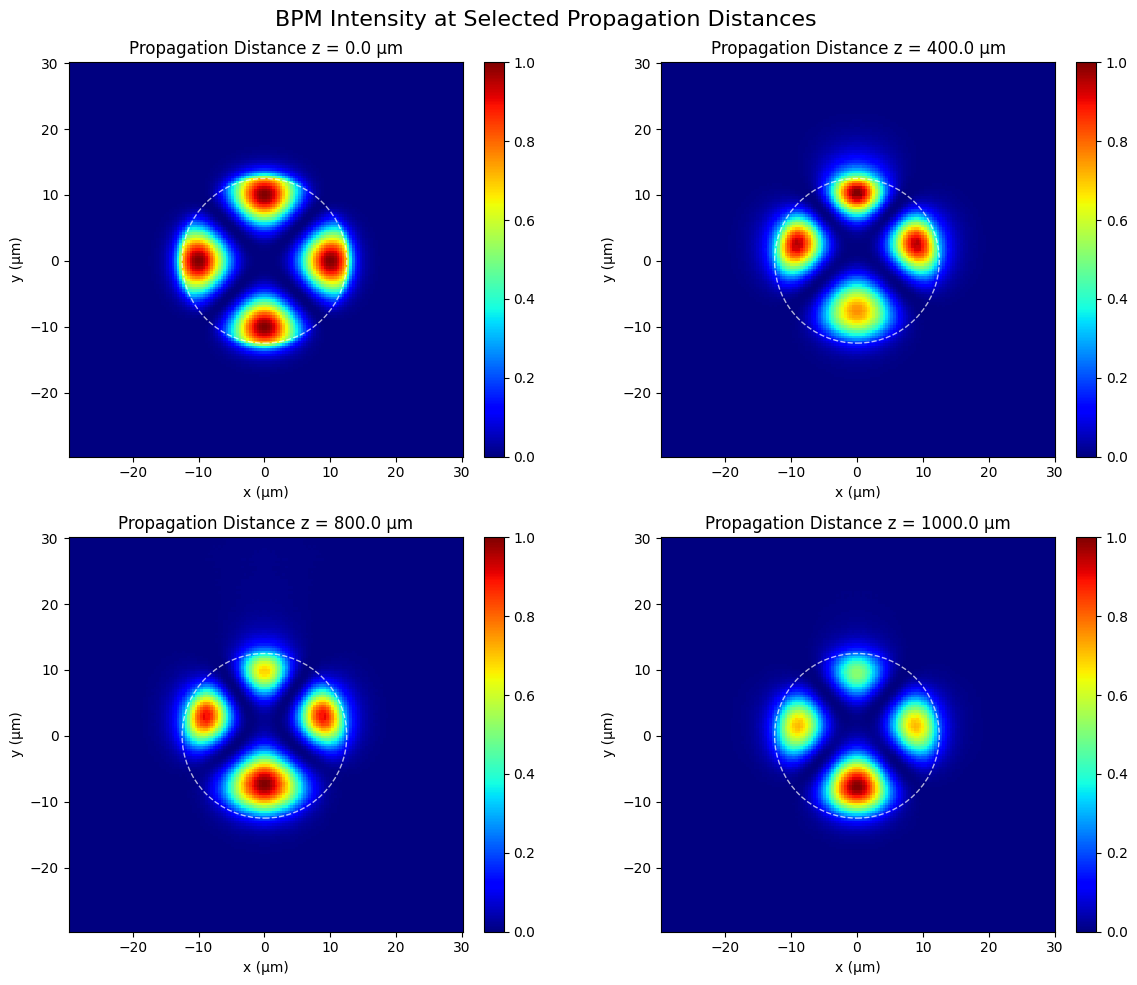

In [89]:
# --- plot
# 1. DEFINE THE ZOOM WINDOW
zoom_half_width = 30.0  # micrometers

# Figure out how many pixels this zoom window covers
zoom_pixels = int(2 * zoom_half_width / dx)

# 2. FIND THE CENTER OF THE GRID AND CROP
center_idx = Nx // 2
half_zoom = zoom_pixels // 2

crop_start = center_idx - half_zoom
crop_end = center_idx + half_zoom

# If the zoom window has an odd number of points, we need to take one
if zoom_pixels % 2 == 1:
    crop_end += 1

# Create the slice object for cropping
zoom_slice = slice(crop_start, crop_end)

# The x and y coordinates for our new zoomed-in view
zoomed_coords = x0[zoom_slice]

# 3. SET UP THE FIGURE (2 rows, 2 columns for the 4 saved z-positions)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("BPM Intensity at Selected Propagation Distances", fontsize=16)

# 4. LOOP THROUGH THE SAVED FIELDS AND PLOT
for axis, (distance_z, full_field) in zip(axes.flat, bpm_results.items()):
    
    # Cut out just the zoomed region from the full 2D field
    zoomed_field = full_field[zoom_slice, zoom_slice]

    intensity = np.abs(zoomed_field) ** 2
    
    # Normalize each frame independently.
    intensity = intensity / intensity.max()
    
    # Plot using pcolormesh. This automatically respects the correct
    image_plot = axis.pcolormesh(
        zoomed_coords, zoomed_coords, intensity,
        cmap='jet', shading='auto', vmin=0, vmax=1
    )
    
    # Draw a white dashed circle to mark the exact boundary of the fiber core
    core_circle = plt.Circle(
        (0, 0), core_radius,
        edgecolor='white', facecolor='none', linestyle='--', alpha=0.7
    )
    axis.add_patch(core_circle)
    
    # Labels and titles
    axis.set_title(f"Propagation Distance z = {distance_z:.1f} µm")
    axis.set_aspect('equal')  # This ensures the core appears as a perfect circle
    axis.set_xlabel("x (µm)")
    axis.set_ylabel("y (µm)")
    
    # Add a colorbar for each subplot
    fig.colorbar(image_plot, ax=axis, fraction=0.046, pad=0.04)

# Remove gaps between the subplots and display
plt.tight_layout()
plt.show()